In [1]:
# fix relative imports
import os
cwd = os.path.normpath(os.getcwd())
cwd = cwd.split(os.sep)
find = cwd.index("fidelity-phase-tran")
newdir = f"{os.sep}".join(cwd[:find+1])
os.chdir(newdir)
%load_ext autoreload
%autoreload 2

import numpy as np
import uuid
import time
import pickle
import gzip
from functools import partial

from tqdm.notebook import tqdm
from tenpy.tools import hdf5_io
import h5py

import matplotlib.pyplot as plt

from qphaset.annni import model_annni_qs_mps
from qphaset.models import drmg_gstate_qs_mps

## Template notebook for running the DMRG for the ANNNI model with `qs-mps`

In [2]:
def guess_state(L):
    """
    guess_state

    This function gives you a product state tensor of all up spins
    for a chain of length L
    
    """
    up = np.array([[[1],[0]]])
    init_tensor = [up for _ in range(L)]
    return init_tensor

def run_model(params, model_factory, gstate_solver):
    t_tot = []
    g_states = []
    for (x,y) in tqdm(params):
        print(f"x: {x}, y:{y}")
        model = model_factory(x, y)
        try:
            print("try with guess state...")
            if y == params[0,-1]:
                init_tensor = guess_state(model.L)
                model.sites = init_tensor.copy()
                model.enlarge_chi()
            else:
                model.sites = init_tensor.copy()
            timer = time.monotonic()
            gstate = gstate_solver(model=model)
            timer = time.monotonic() - timer
        except:
            print("try with random state...")
            model._random_state(seed=3, type_shape="rectangular")
            model.canonical_form()
            timer = time.monotonic()
            gstate = gstate_solver(model=model)
            timer = time.monotonic() - timer
        t_tot.append(timer)
        g_states.append(model.sites.copy())
        init_tensor = model.sites.copy()
    statistics = dict(times=t_tot)
    return g_states, statistics

In [3]:
# *** Data sampling (Hamitonian parameters grid) ***

n = 10  # Sampling grid size

# params = np.linspace(0.01, 1.5, n), np.linspace(0.01, 1.5, n)
params = np.linspace(0.1, 1.5, n), np.linspace(1.5, 0.1, n) # upside-down
# params = np.linspace(0.01, 1., n), np.linspace(1., 0.01, n)   # Good one
# params = np.linspace(0.5, 1.5, n), np.linspace(1., 0.2, n)      # Floating phase detail
# params = np.linspace(0.5, 1.5, n), np.linspace(0.8, 0.01, n)      # Floating phase detail (lowered)
# params = np.linspace(0.01, 1., n), np.linspace(0.8, 0.01, n)      # Floating phase detail (lowered) + multi-critical point
# params = np.linspace(0.6, 1.5, n), np.linspace(0.1, 1.5, n)      # Floating phase detail ++

params = map(lambda m: m.flatten(), np.meshgrid(*params, indexing='xy'))
params = tuple(params)
params = np.stack(params).T

In [14]:
# *** Config ***

l = 20  # Number of spins

model_name = 'ANNNI'
model_factory = partial(model_annni_qs_mps, c1=-1, chi=64)
dmrg_params = {
    #'mixer': True,
    #'max_E_err': 1.e-16,
    #'chi_list': {0: 25, 10: 50, 20: 100},
    'type_shape': "rectangular",
    'trunc_params': {
       'trunc_tol': False,
       'trunc_chi': True
    #   'svd_min': 1.e-16
    },
    'd': 2,
    'max_hours': 16 / 3600
    #'combine': True
}

In [15]:
# *** Solver ***

gstates, stats = run_model(params,
                        model_factory=partial(model_factory, l=l),
                        gstate_solver=partial(drmg_gstate_qs_mps, dmrg_params=dmrg_params))

  0%|          | 0/100 [00:00<?, ?it/s]

x: 0.1, y:1.5
try with guess state...
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 39
total time: 3.475811051001074
##############################
x: 0.25555555555555554, y:1.5
try with guess state...
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 39
total time: 3.1475980169998365
##############################
x: 0.4111111111111111, y:1.5
try with guess state...
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 39
total time: 3.0386669950003125
##############################
x: 0.5666666666666667, y:1.5
try with guess state...
Sweep n: 0

Sweep n: 1

##############################
The energy between the tw

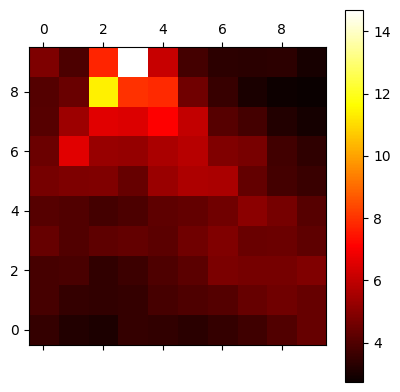

In [16]:
# *** Execution time per pixel ***

plt.matshow(np.array(stats['times']).reshape((n, n)), cmap='hot', origin='lower')
plt.colorbar()

## Save `pickle`

In [17]:
# *** Data export ***

filename = f'results/data/{model_name}-{str(uuid.uuid4())}.pkl' 
data = dict(params=params, dmrg_params=dmrg_params,
            l=l, n=n, model_name=model_name,
            gstates=gstates, stats=stats)
with gzip.open(filename, 'wb') as f:
    pickle.dump(data, f)

## Save `hdf5`

In [8]:
data = dict(params=params, dmrg_params=dmrg_params,
            l=l, n=n, model_name=model_name,
            gstates=gstates, stats=stats)

In [9]:
# Looking at the extent of the parameters explored (all just double checking all is okay!)
params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])
print(params_extent)
print(np.shape(params))

(0.1, 1.5, 0.1, 1.5)
(100, 2)


In [10]:
# Taking the tensors
tensor_list =  data["gstates"]

# Convert the list to a 64x64 nested list
matrix_64x64 = [tensor_list[i*64:(i+1)*64] for i in range(64)]
# Flip the nested list vertically
flipped_matrix = matrix_64x64[::-1]
# Flatten the nested list back into a single list
corrected_list = [item for sublist in flipped_matrix for item in sublist]

In [11]:
# Creating data dictionary to be saved 
data_h5 = {#"gstates": gstates,  # list of MPS - tensors 
        "gstates": corrected_list, # Flipped list
        "params_extent": params_extent, # (2, N) evenly spaced - in future 
        "n": data["n"],
        "l": data["l"], # Number of qubits (L)
        "dmrg_params": data["dmrg_params"], # DMRG params used in calculation - converting? hashtable 
        "info": {"model_type":"ANNNI",}, # Additional info 
        "times": np.array(data["stats"]["times"]), # Times for DMRG } # params swept 
}

In [12]:
# Saving your file, make sure to change the name to the name you want to store your file in! 
filename_to_save = f"results/data/{model_name}-{str(uuid.uuid4())}.h5"
with h5py.File(filename_to_save, 'w') as f:
    hdf5_io.save_to_hdf5(f, data_h5)